In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df=pd.read_csv("ecommerce_sales_data.csv")

In [53]:
df.head(10)

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
5,2023-12-01,Camera,Electronics,West,1,524,106.35
6,2023-10-09,Headphones,Accessories,North,7,6167,1027.98
7,2022-01-14,Camera,Electronics,South,7,3059,873.50
8,2022-04-02,Smartwatch,Electronics,East,9,5526,595.28
9,2024-10-22,Printer,Office,South,8,672,186.37


In [54]:
df.shape

(3500, 7)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [56]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [57]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [58]:
df.duplicated().any()

np.False_

In [59]:
df['Product Name'].value_counts()

Product Name
Monitor       364
Camera        363
Smartwatch    363
Printer       357
Keyboard      351
Tablet        350
Mouse         347
Headphones    339
Laptop        336
Smartphone    330
Name: count, dtype: int64

In [60]:
df['Category'].value_counts()

Category
Electronics    1742
Accessories    1401
Office          357
Name: count, dtype: int64

In [61]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


In [62]:
df['Month']=df['Order Date'].dt.month_name()
df['Year']=df['Order Date'].dt.year

In [63]:
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Month,Year
0,2024-12-31,Printer,Office,North,4,3640,348.93,December,2024
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,November,2022
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,May,2022
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,March,2024
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,September,2022
...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16,February,2023
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89,September,2022
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02,April,2022
3498,2022-01-18,Printer,Office,South,3,222,50.28,January,2022


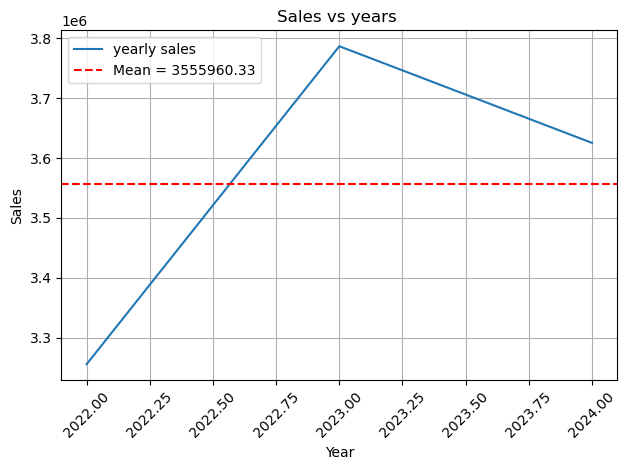

In [94]:
x=df.groupby(df["Year"])["Sales"].sum().reset_index()
mean_sales=x['Sales'].mean()
plt.plot(x['Year'],x['Sales'], label='yearly sales')
plt.axhline(y=mean_sales, linestyle='--',color='red', label=f'Mean = {mean_sales:.2f}')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title("Sales vs years ")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

#There is a decline in sales after 2023. The average yearly sales are 3,555,960.33.

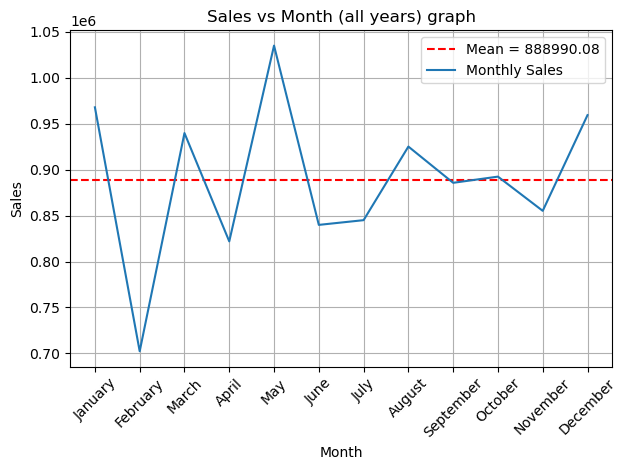

In [95]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
x=df.groupby(df["Month"])["Sales"].sum().reindex(month_order).reset_index()
mean_sales=x['Sales'].mean()
plt.axhline(y=mean_sales, linestyle='--',color='red', label=f'Mean = {mean_sales:.2f}')
plt.plot(x['Month'],x['Sales'], label='Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title("Sales vs Month (all years) graph")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# Sales peaked in May, while February recorded the lowest sales.
# The average monthly sales across all years is 888,990.08.

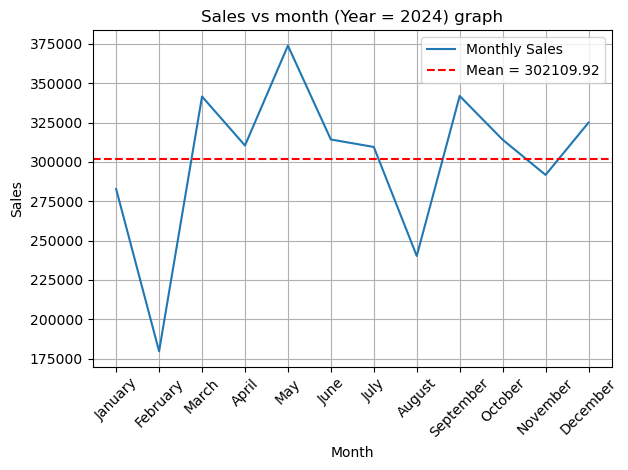

In [134]:
latest_year=df['Year'].max()
df_latest=df[df['Year']==latest_year]
x=df_latest.groupby(df_latest["Month"])["Sales"].sum().reindex(month_order).reset_index()
plt.plot(x['Month'],x['Sales'], label='Monthly Sales')
mean_sales=x['Sales'].mean()
plt.axhline(y=mean_sales, linestyle='--',color='red', label=f'Mean = {mean_sales:.2f}')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title("Sales vs month (Year = 2024) graph")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# In 2024 (latest year), sales reached their lowest point in February, peaked in May, declined in August, and increased again in September.
# The average sales for the year were 302,109.92.

'Monitors, smartwatches, and cameras are the most frequently sold products.\nHowever, cameras and monitors generate the highest revenue and profit, indicating that although smartwatches have strong demand,\nthey contribute relatively less to overall revenue.\n\nThe Electronics category dominates in both sales and profitability, making it the most significant contributor to overall business performance.\n\nIn contrast, headphones record the lowest sales, while tablets generate the least profit.\nAdditionally, headphones and smartphones are among the least sold products.\n\nOverall, the differences in sales, profit, and quantity across products are not highly significant,\nas most products fall within a similar range of performance.'

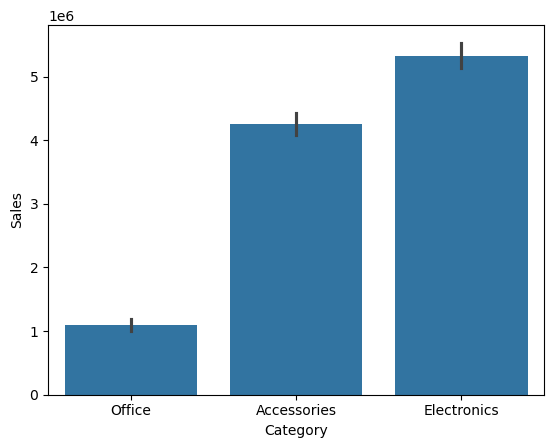

In [121]:
sns.barplot(x="Category",y="Sales", data=df, estimator=sum)
'''Monitors, smartwatches, and cameras are the most frequently sold products.
However, cameras and monitors generate the highest revenue and profit, indicating that although smartwatches have strong demand,
they contribute relatively less to overall revenue.

The Electronics category dominates in both sales and profitability, making it the most significant contributor to overall business performance.

In contrast, headphones record the lowest sales, while tablets generate the least profit.
Additionally, headphones and smartphones are among the least sold products.

Overall, the differences in sales, profit, and quantity across products are not highly significant,
as most products fall within a similar range of performance.'''

<Axes: xlabel='Category', ylabel='Profit'>

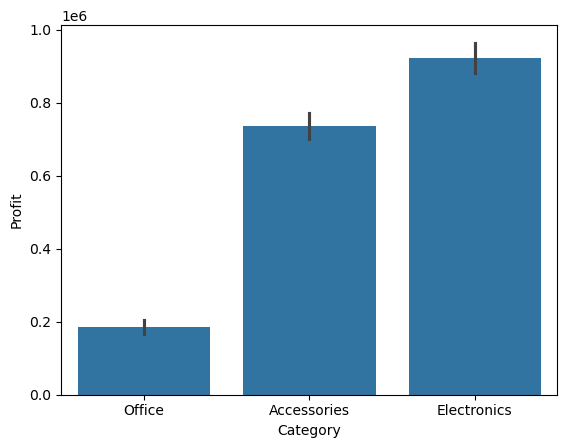

In [105]:
sns.barplot(x="Category",y="Profit", data=df, estimator=sum)

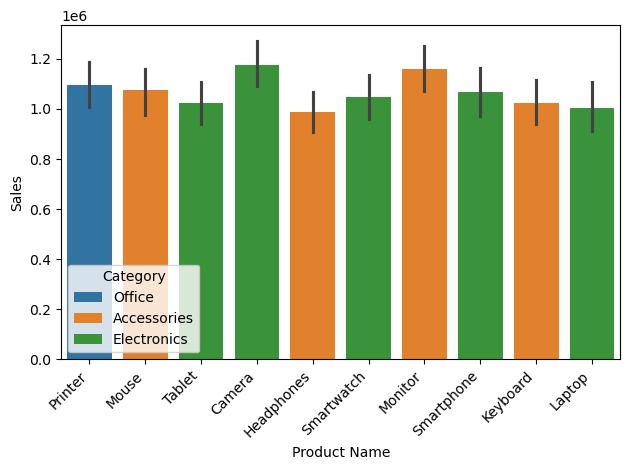

In [108]:
sns.barplot(x="Product Name",y="Sales",hue='Category', data=df, estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

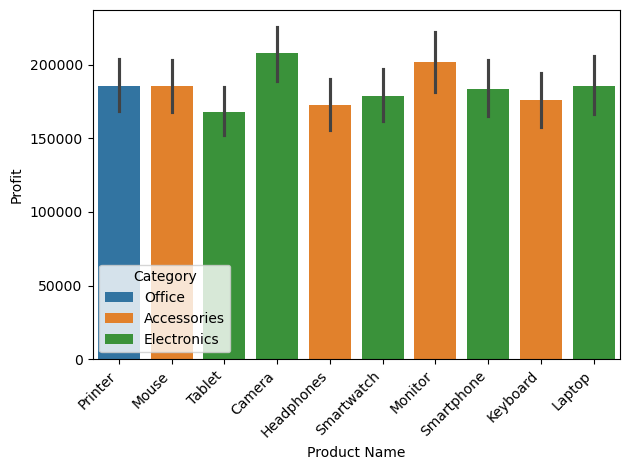

In [109]:
sns.barplot(x="Product Name",y="Profit",hue='Category', data=df, estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

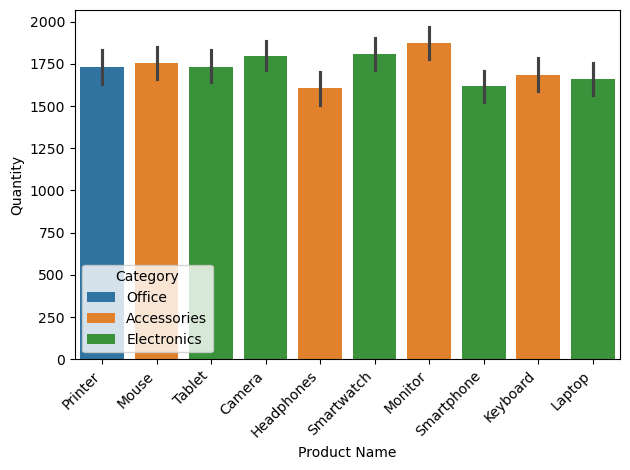

In [112]:
sns.barplot(x="Product Name",y="Quantity", hue='Category', data=df, estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

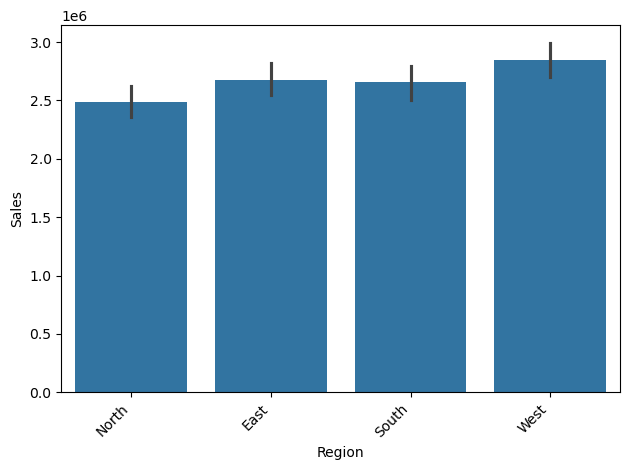

In [119]:
sns.barplot(x="Region",y="Sales", data=df, estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#all the regions contribute equally in sales and profit but western region has more sales and profit to othersand north region has minimum

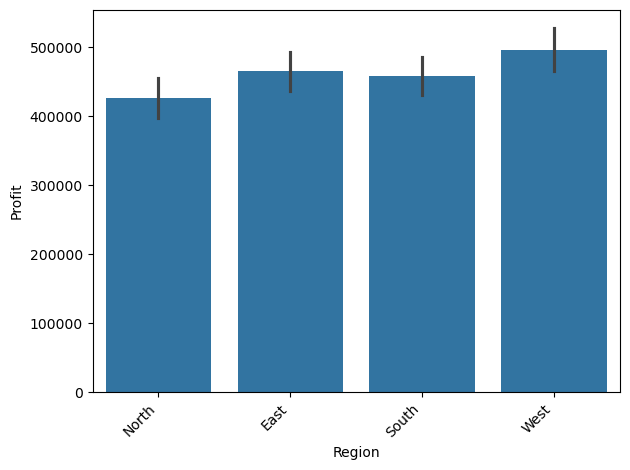

In [120]:
sns.barplot(x="Region",y="Profit", data=df, estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

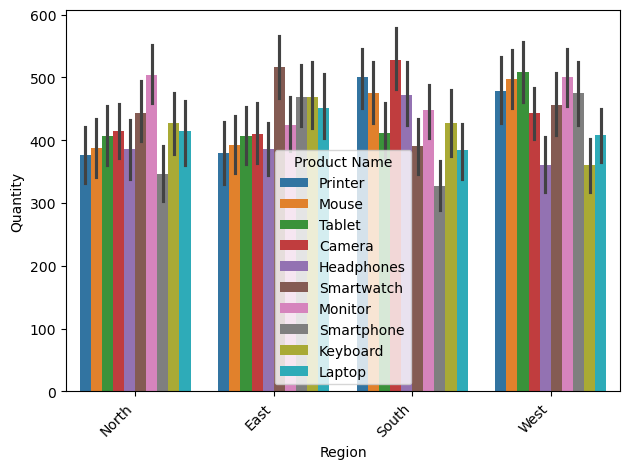

In [122]:
sns.barplot(x="Region",y="Quantity", data=df,hue='Product Name', estimator=sum)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# north region has highest demand of headphones, east has smartwatch, south has camera, printer, west has tablet, Mouse, Monitor , printer
# and north region has least demand of smartphone, east hasheadphones, printer, south has smartphone, west has headphones ,  keyboard

'There is a strong positive relationship between sales and profit, \nindicating consistent profitability across transactions.\nHowever, the variation in profit for similar sales values suggests differences in profit margins across products and categories, \nwith Electronics generally showing higher profitability at higher sales levels.'

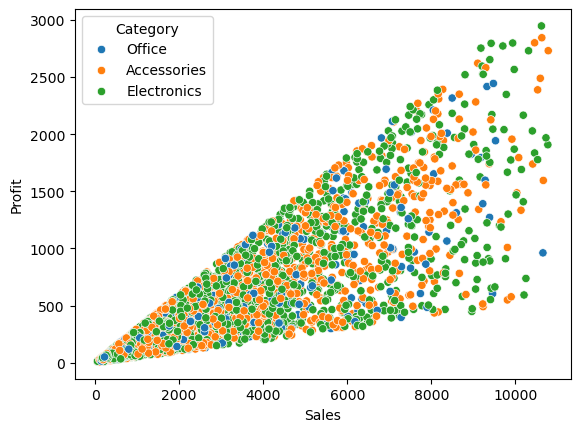

In [141]:
sns.scatterplot(x='Sales',y='Profit',hue='Category',data=df)
'''There is a strong positive relationship between sales and profit, 
indicating consistent profitability across transactions.
However, the variation in profit for similar sales values suggests differences in profit margins across products and categories, 
with Electronics generally showing higher profitability at higher sales levels.'''

<Axes: xlabel='Quantity', ylabel='Sales'>

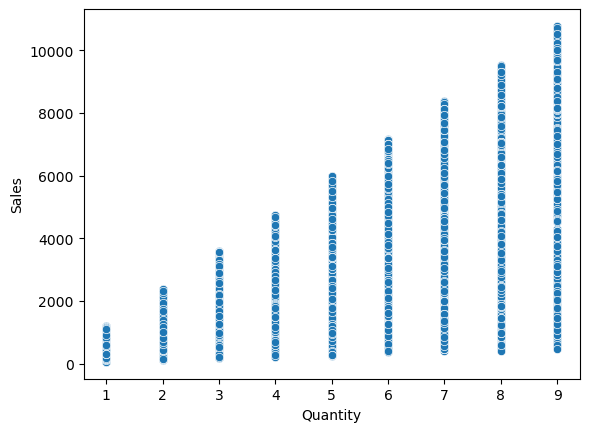

In [137]:
sns.scatterplot(x='Quantity',y='Sales',data=df)

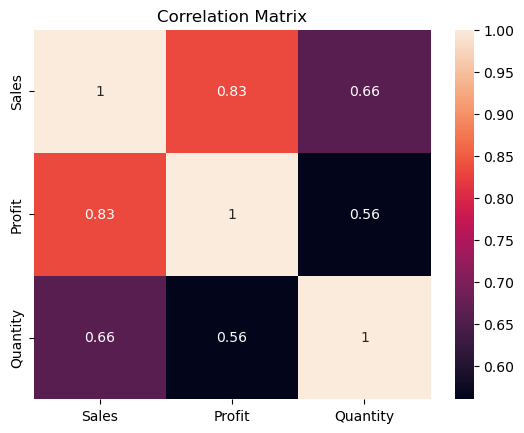

'The correlation analysis shows a strong positive relationship between sales and profit (0.83), \nindicating that higher revenue significantly contributes to profitability. \nHowever, the weaker correlation between quantity and profit (0.56) suggests that increased sales volume alone does not guarantee higher profit, \nhighlighting the importance of pricing and profit margins.'

In [140]:
corr = df[['Sales', 'Profit', 'Quantity']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()
'''The correlation analysis shows a strong positive relationship between sales and profit (0.83), 
indicating that higher revenue significantly contributes to profitability. 
However, the weaker correlation between quantity and profit (0.56) suggests that increased sales volume alone does not guarantee higher profit, 
highlighting the importance of pricing and profit margins.'''

# Insights 
### Sales Trends & Seasonality
Sales show a decline after 2023, indicating a potential slowdown in recent performance.
Sales consistently peak in May and reach their lowest point in February, suggesting strong seasonal patterns.
In 2024, sales followed a similar pattern: lowest in February, peak in May, dip in August, and recovery in September.
The average yearly sales are 3,555,960.33, while average monthly sales across all years are 888,990.08.
The average monthly sales in 2024 were 302,109.92, indicating comparatively lower performance.

### Product Performance
Monitors, smartwatches, and cameras are the most frequently sold products (high demand).
However, cameras and monitors generate the highest revenue and profit, making them key business drivers.
Smartwatches, despite high demand, contribute relatively less to revenue, indicating lower pricing or margins.
Headphones have the lowest sales, while tablets generate the least profit.
Overall, product performance differences are moderate, with most products operating within a similar range.

### Category Insights
The Electronics category dominates in both sales and profit, making it the most critical category for the business.
It also shows higher profitability at higher sales levels, indicating strong margins.

### Regional Insights
All regions contribute relatively similarly to sales and profit, indicating a balanced market.
The West region performs slightly better, while the North region shows comparatively lower performance.
Regional Demand Patterns:
North → Highest: Headphones | Lowest: Smartphones
East → Highest: Smartwatches | Lowest: Headphones, Printers
South → Highest: Cameras, Printers | Lowest: Smartphones
West → Highest: Tablets, Monitors, Mouse, Printers | Lowest: Headphones, Keyboard

### Sales–Profit Relationship
There is a strong positive relationship between sales and profit, indicating consistent profitability.
However, profit varies at similar sales levels, showing differences in profit margins across products and categories.
Electronics tend to achieve higher profit at higher sales levels.

### Correlation Insights
Sales and Profit (0.83) → strong positive correlation
Sales and Quantity (0.66) → moderate correlation
Profit and Quantity (0.56) → weaker correlation

Profit depends more on revenue (sales) than just volume (quantity), highlighting the importance of pricing and margins.

# Conclusion
The analysis reveals clear patterns in sales performance, product contribution, and regional demand, providing a comprehensive view of the business. Sales exhibit strong seasonality, consistently peaking in May and reaching their lowest levels in February, while a noticeable decline after 2023 suggests a potential slowdown that may require further investigation.

From a product perspective, although monitors, smartwatches, and cameras are the most frequently sold items, cameras and monitors emerge as the primary drivers of revenue and profit. This indicates that high demand does not always translate into high profitability, as seen with smartwatches, emphasizing the importance of pricing and profit margins.

At the category level, Electronics dominates both sales and profitability, making it the most critical segment for the business. Regionally, performance is relatively balanced, though variations in product preferences across regions highlight the need for more localized strategies.

Furthermore, the strong positive relationship between sales and profit confirms consistent revenue generation, while the weaker association between quantity and profit underscores that higher sales volume alone does not guarantee increased profitability. This reinforces the importance of focusing on high-margin products rather than solely on sales volume.

Overall, the findings suggest that the business performs steadily across products and regions, with moderate variation in performance. However, future growth can be driven by prioritizing high-profit products, optimizing underperforming items, and addressing the recent decline in sales trends.